# 🏠 EDA Complète - Dataset Immobilier Mauritanie
## Analyse Exploratoire des Données pour la Régression

**Objectif** : Prédire le **prix de vente** (`prix`) d'un bien immobilier en Mauritanie (Nouakchott) à partir de ses caractéristiques.

Ce notebook suit la **Roadmap EDA** étape par étape :
1. 📥 Chargement & Inspection initiale
2. 🧹 Nettoyage de base
3. ❓ Traitement des valeurs manquantes (MCAR / MAR / MNAR)
4. 🔍 Détection d'outliers
5. 📊 Analyse univariée
6. 📈 Analyse bivariée
7. 🧮 Analyse multivariée
8. ⚙️ Préparation finale

---

**Dataset** : Immobilier Mauritanie - Données collectées via web scraping  
**Variable cible** : `prix` (en MRU - Ouguiya mauritanien)  
**Contexte** : Marché immobilier de Nouakchott et Nouadhibou

> 💡 *Projet Capstone - SupNum - Machine Learning Course - Mohamed*

## 🔧 Setup - Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False  # Pour éviter les problèmes avec les signes moins

# Configuration du chemin des données
project_root = Path().resolve().parent
data_path = project_root / 'data' / 'raw' / 'kaggle_train.csv'

print("✅ Librairies chargées !")
print(f"📁 Chemin des données : {data_path}")

✅ Librairies chargées !
📁 Chemin des données : /home/bechir/Documents/immobilier-price-prediction/data/raw/kaggle_train.csv


# 📖 Dictionnaire de Données - Dataset Immobilier Mauritanie

> **Contexte** : Données immobilières collectées via web scraping sur les sites d'annonces mauritaniens. Chaque ligne représente une annonce immobilière.
> **Variable cible** : `prix` (prix de vente en MRU - Ouguiya mauritanien)

---

## 🏷️ Identification

| Variable | Type | Description |
|----------|------|-------------|
| `id` | int | Identifiant unique de chaque observation |

## 🏗️ Caractéristiques générales

| Variable | Type | Description |
|----------|------|-------------|
| `titre` | str | Titre de l'annonce (peut contenir du texte en arabe) |
| `surface_m2` | num | Surface du bien en mètres carrés |
| `nb_chambres` | num | Nombre de chambres |
| `nb_salons` | num | Nombre de salons |
| `nb_sdb` | num | Nombre de salles de bain |
| `quartier` | cat | Quartier de Nouakchott : Tevragh Zeina, Ksar, Arafat, Dar Naim, Toujounine, Sebkha, El Mina, Riyad, Teyarett |

## 💰 Prix

| Variable | Type | Description |
|----------|------|-------------|
| `prix` | num | **🎯 VARIABLE CIBLE** — Prix de vente en MRU (Ouguiya mauritanien) |

## 📝 Descriptif

| Variable | Type | Description |
|----------|------|-------------|
| `description` | str | Description textuelle du bien (peut contenir du texte en arabe) |
| `caracteristiques` | str | Caractéristiques séparées par `\|` : "Garage \| Piscine \| Climatisation" |

## 📍 Métadonnées

| Variable | Type | Description |
|----------|------|-------------|
| `source` | cat | Source de l'annonce : voursa.com, mauriannonces.com, etc. |
| `date_publication` | date | Date de publication de l'annonce (format YYYY-MM-DD) |

## 🌍 Géographique (si enrichi)

| Variable | Type | Description |
|----------|------|-------------|
| `latitude` | num | Coordonnée GPS latitude |
| `longitude` | num | Coordonnée GPS longitude |
| `dist_centre_ville_km` | num | Distance au centre-ville (Ksar) en km |
| `dist_aeroport_km` | num | Distance à l'aéroport Oumtounsy en km |
| `dist_plage_km` | num | Distance à la plage en km |
| `nb_ecoles_1km` | num | Nombre d'écoles dans un rayon de 1 km |
| `nb_mosquees_1km` | num | Nombre de mosquées dans un rayon de 1 km |
| `nb_commerces_1km` | num | Nombre de commerces dans un rayon de 1 km |
| `nb_hopitaux_1km` | num | Nombre d'hôpitaux/cliniques dans un rayon de 1 km |
| `nb_total_pois_1km` | num | Total de Points d'Intérêt dans un rayon de 1 km |

---

## ⚠️ Légende des mécanismes de valeurs manquantes

| Tag | Mécanisme | Signification |
|-----|-----------|---------------|
| **MCAR** | Missing Completely At Random | NaN aléatoire, aucun lien avec d'autres variables |
| **MAR** | Missing At Random | NaN dépend d'une autre variable observée (ex: terrain → nb_sdb = NaN) |
| **MNAR** | Missing Not At Random | NaN dépend de la valeur elle-même (ex: "Prix sur demande" → prix = NaN) |

---
## 📥 Étape 1 : Chargement & Inspection initiale

> **Objectif** : Comprendre la structure — dimensions, types, aperçu, doublons, cohérence des formats.

In [2]:
# Charger les données
df = pd.read_csv(data_path, encoding='utf-8')
print(f"📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"📊 Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

📐 Dimensions : 1153 lignes × 12 colonnes
📊 Mémoire : 1.0 MB


In [3]:
# Aperçu des premières lignes
df.head()

,id,titre,prix,surface_m2,nb_chambres,nb_salons,nb_sdb,quartier,description,caracteristiques,source,date_publication
0,1076,منزل احذ اللنكات حمام الياسمين,1800000.0,150.0,3.0,2.0,NaN,Arafat,دار للبيع اعل شارع اكبير احذ حمام الياسمين الل...,Titre foncier | 1 balcon(s) | Taille rue: 15.0...,voursa.com,2025-09-13
1,875,فرصة دار مكونه من طابقين ارضي و واحد فوقوني كا...,1800000.0,300.0,6.0,3.0,NaN,Tevragh Zeina,فرصة دار ، الطابق الأرضي يحتاج ترميم بسبب المل...,1 balcon(s) | Taille rue: N/A | Proche de: كرف...,voursa.com,2025-07-06
2,453,دار فتيارت فاتح فبرك,900000.0,216.0,1.0,1.0,NaN,Teyarett,سعر 9ملايين مدخله 50الف حد شاري ول عندو طلب تل...,Titre foncier | type de propriété: Autre | 1 b...,voursa.com,2026-01-20
3,987,دار للبيـــــــــــــــــــــع أفي عين الطلح,1600000.0,150.0,3.0,1.0,2.0,Teyarett,السلام عليكم ذاك دار للبيـــــــــــــــــــــ...,NaN,voursa.com,2025-12-09
4,252,ملح سكتير 2,800000.0,180.0,3.0,2.0,NaN,Toujounine,السلام عليكم \nفرصة للبيـــــــــــــــــــــع...,Titre foncier | 1 balcon(s) | Taille rue: 25.0...,voursa.com,2025-04-18


In [4]:
# Types de variables
print("📋 Types de variables :")
print(df.dtypes.value_counts())
print(f"\n🔢 Numériques : {df.select_dtypes(include='number').shape[1]}")
print(f"🏷️  Catégorielles : {df.select_dtypes(include='object').shape[1]}")

📋 Types de variables :
object     6
float64    5
int64      1
Name: count, dtype: int64

🔢 Numériques : 6
🏷️  Catégorielles : 6


In [5]:
# Informations détaillées
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1153 non-null   int64  
 1   titre             1153 non-null   object 
 2   prix              1153 non-null   float64
 3   surface_m2        1153 non-null   float64
 4   nb_chambres       1139 non-null   float64
 5   nb_salons         1153 non-null   float64
 6   nb_sdb            320 non-null    float64
 7   quartier          1153 non-null   object 
 8   description       1153 non-null   object 
 9   caracteristiques  996 non-null    object 
 10  source            1153 non-null   object 
 11  date_publication  1153 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 108.2+ KB


In [6]:
# Valeurs uniques par variable
print("🔑 Valeurs uniques par variable :")
for col in df.columns:
    print(f"  {col:20s} → {df[col].nunique():5d} uniques  |  type: {df[col].dtype}")

🔑 Valeurs uniques par variable :
  id                   →  1153 uniques  |  type: int64
  titre                →  1072 uniques  |  type: object
  prix                 →   155 uniques  |  type: float64
  surface_m2           →    77 uniques  |  type: float64
  nb_chambres          →    14 uniques  |  type: float64
  nb_salons            →    14 uniques  |  type: float64
  nb_sdb               →    10 uniques  |  type: float64
  quartier             →     8 uniques  |  type: object
  description          →  1144 uniques  |  type: object
  caracteristiques     →   808 uniques  |  type: object
  source               →     1 uniques  |  type: object
  date_publication     →   329 uniques  |  type: object


In [7]:
# Détection des doublons (hors id)
duplicates = df.drop(columns='id').duplicated()
print(f"🔁 Doublons (hors id) : {duplicates.sum()}")
if duplicates.sum() > 0:
    print("\n📌 Lignes dupliquées :")
    display(df[duplicates])

🔁 Doublons (hors id) : 0


### 🎯 Observations Étape 1
- **Dimensions** : Nombre de lignes et colonnes
- **Doublons détectés** → à traiter étape 2
- **Variable cible** : `prix` (continue → régression)

---
## 🧹 Étape 2 : Nettoyage de base

> **Objectif** : Supprimer doublons, corriger formats, appliquer règles métier, uniformiser catégories.

In [9]:
# 2.1 — Supprimer les doublons
print(f"Avant : {len(df)} lignes")
df = df.drop_duplicates(subset=df.columns.difference(['id']), keep='first').reset_index(drop=True)
print(f"Après : {len(df)} lignes")

Avant : 1153 lignes
Après : 1153 lignes


In [10]:
# 2.2 — Standardiser les quartiers
# Mapping des variantes de quartiers
quartier_mapping = {
    'Riyadh': 'Riyad',  # Variante orthographique
    'Tevragh-Zeina': 'Tevragh Zeina',
    'TevraghZeina': 'Tevragh Zeina',
    'Tevragh zeina': 'Tevragh Zeina',
    'tevragh zeina': 'Tevragh Zeina',
    'TEVRAGH ZEINA': 'Tevragh Zeina',
}

# Appliquer le mapping
df['quartier'] = df['quartier'].replace(quartier_mapping)

# Standardiser en Title Case
df['quartier'] = df['quartier'].str.title()

print("✅ Quartiers standardisés")
print(f"📊 Quartiers uniques : {df['quartier'].nunique()}")
print(df['quartier'].value_counts().head(10))

✅ Quartiers standardisés
📊 Quartiers uniques : 8
quartier
Tevragh Zeina    373
Teyarett         270
Arafat           244
Toujounine       115
Dar Naim          82
Ksar              46
Riyad             13
Sebkha            10
Name: count, dtype: int64


In [11]:
# 2.3 — Nettoyer les prix
print("💰 Vérification des prix :")
print(f"  Prix négatifs : {(df['prix'].dropna() < 0).sum()}")
print(f"  Prix nuls : {df['prix'].isna().sum()}")
print(f"  Prix = 0 : {(df['prix'] == 0).sum()}")

# Remplacer les valeurs négatives par NaN
if (df['prix'].dropna() < 0).sum() > 0:
    df.loc[df['prix'] < 0, 'prix'] = np.nan
    print("  ✅ Prix négatifs remplacés par NaN")

# Statistiques des prix
print(f"\n📊 Statistiques des prix (MRU) :")
print(df['prix'].describe())

💰 Vérification des prix :
  Prix négatifs : 0
  Prix nuls : 0
  Prix = 0 : 0

📊 Statistiques des prix (MRU) :
count    1.153000e+03
mean     4.339931e+06
std      5.451494e+06
min      2.000000e+05
25%      1.300000e+06
50%      2.600000e+06
75%      5.800000e+06
max      5.400000e+07
Name: prix, dtype: float64


In [12]:
# 2.4 — Nettoyer les surfaces
print("🏗️ Vérification des surfaces :")
for col in ['surface_m2']:
    if col in df.columns:
        neg = (df[col].dropna() < 0).sum()
        if neg > 0:
            print(f"  ❌ {col} : {neg} valeurs négatives → remplacées par NaN")
            df.loc[df[col] < 0, col] = np.nan
        else:
            print(f"  ✅ {col} : OK")
        
        # Détecter valeurs aberrantes (> 10000 m²)
        extreme = (df[col].dropna() > 10000).sum()
        if extreme > 0:
            print(f"  ⚠️  {col} : {extreme} valeurs > 10000 m² (à vérifier)")

🏗️ Vérification des surfaces :
  ✅ surface_m2 : OK


In [13]:
# 2.5 — Parser les caractéristiques
# Extraire les features booléennes depuis la colonne 'caracteristiques'

def parse_caracteristiques(caracteristiques_str):
    """Parse la colonne caractéristiques et retourne un dictionnaire de features booléennes"""
    if pd.isna(caracteristiques_str) or caracteristiques_str == '':
        return {}
    
    features = {}
    # Séparer par |
    parts = str(caracteristiques_str).split('|')
    
    # Features à détecter
    feature_keywords = {
        'has_garage': ['garage', 'Garage', 'GARAGE'],
        'has_piscine': ['piscine', 'Piscine', 'PISCINE', 'pool', 'Pool'],
        'has_clim': ['climatisation', 'Climatisation', 'clim', 'Clim', 'air conditionné'],
        'has_balcon': ['balcon', 'Balcon', 'BALCON'],
        'has_titre_foncier': ['Titre foncier', 'titre foncier'],
        'has_camera': ['Caméra', 'caméra', 'camera', 'sécurité'],
    }
    
    caracteristiques_lower = caracteristiques_str.lower()
    
    for feature_name, keywords in feature_keywords.items():
        features[feature_name] = any(keyword.lower() in caracteristiques_lower for keyword in keywords)
    
    return features

# Appliquer le parsing
caracteristiques_parsed = df['caracteristiques'].apply(parse_caracteristiques)

# Créer les colonnes booléennes
for feature_name in ['has_garage', 'has_piscine', 'has_clim', 'has_balcon', 'has_titre_foncier', 'has_camera']:
    df[feature_name] = caracteristiques_parsed.apply(lambda x: x.get(feature_name, False))

print("✅ Caractéristiques parsées")
print(f"\n📊 Fréquence des caractéristiques :")
for col in ['has_garage', 'has_piscine', 'has_clim', 'has_balcon', 'has_titre_foncier', 'has_camera']:
    print(f"  {col}: {df[col].sum()} ({df[col].mean()*100:.1f}%)")

✅ Caractéristiques parsées

📊 Fréquence des caractéristiques :
  has_garage: 472 (40.9%)
  has_piscine: 0 (0.0%)
  has_clim: 0 (0.0%)
  has_balcon: 796 (69.0%)
  has_titre_foncier: 480 (41.6%)
  has_camera: 97 (8.4%)


### 2.7 — Extraction avancée de features depuis `caracteristiques`

> Extraction de **taille_rue**, **nb_balcons**, **type_propriete**, **has_meuble** et comptage total des caractéristiques.

In [ ]:
import re

# 2.7.1 — Extraire taille_rue (largeur de la rue en mètres)
def extract_taille_rue(s):
    if pd.isna(s): return np.nan
    m = re.search(r'Taille rue:\s*([\d.]+)', str(s))
    if m:
        val = float(m.group(1))
        return val if 0 < val <= 100 else np.nan  # Filtrer les valeurs aberrantes
    return np.nan

df['taille_rue'] = df['caracteristiques'].apply(extract_taille_rue)

# 2.7.2 — Extraire nb_balcons (nombre de balcons)
def extract_nb_balcons(s):
    if pd.isna(s): return 0
    m = re.search(r'(\d+)\s*balcon', str(s))
    val = int(m.group(1)) if m else 0
    return val if val <= 10 else 0  # Filtrer les valeurs aberrantes

df['nb_balcons'] = df['caracteristiques'].apply(extract_nb_balcons)

# 2.7.3 — Extraire type_propriete
def extract_type_propriete(s):
    if pd.isna(s): return 'Inconnu'
    m = re.search(r'type de propriété:\s*([^|]+)', str(s))
    return m.group(1).strip() if m else 'Inconnu'

df['type_propriete'] = df['caracteristiques'].apply(extract_type_propriete)

# 2.7.4 — has_meuble
df['has_meuble'] = df['caracteristiques'].fillna('').str.lower().str.contains('meublé|meuble').astype(int)

# 2.7.5 — Compter le nombre total de caractéristiques
df['nb_total_carac'] = df['caracteristiques'].fillna('').apply(
    lambda x: len(x.split('|')) if x.strip() else 0
)

print("✅ Features avancées extraites depuis 'caracteristiques' :")
print(f"\n📏 taille_rue :")
print(f"   Non-null : {df['taille_rue'].notna().sum()}/{len(df)} ({df['taille_rue'].notna().mean()*100:.1f}%)")
print(f"   Stats : min={df['taille_rue'].min():.0f}, médiane={df['taille_rue'].median():.0f}, max={df['taille_rue'].max():.0f}")

print(f"\n🏠 nb_balcons :")
print(df['nb_balcons'].value_counts().head())

print(f"\n🏗️ type_propriete :")
print(df['type_propriete'].value_counts())

print(f"\n🛋️ has_meuble : {df['has_meuble'].sum()} ({df['has_meuble'].mean()*100:.1f}%)")
print(f"\n📊 nb_total_carac : moy={df['nb_total_carac'].mean():.1f}, max={df['nb_total_carac'].max()}")

In [ ]:
# 2.7.6 — Corrélation des nouvelles features avec le prix
print("📊 Corrélation des nouvelles features avec prix :")
new_features = ['taille_rue', 'nb_balcons', 'has_meuble', 'nb_total_carac']
for feat in new_features:
    corr_p = df[feat].corr(df['prix'])
    corr_s = df[feat].corr(df['prix'], method='spearman')
    print(f"  {feat:20s} → Pearson={corr_p:.4f} | Spearman={corr_s:.4f}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Taille rue vs Prix
ax = axes[0, 0]
mask_taille = df['taille_rue'].notna()
ax.scatter(df.loc[mask_taille, 'taille_rue'], df.loc[mask_taille, 'prix'], alpha=0.3, s=15)
ax.set_xlabel('Taille rue (m)')
ax.set_ylabel('Prix (MRU)')
ax.set_title(f"Taille rue vs Prix (r={df['taille_rue'].corr(df['prix']):.3f})")

# Nb balcons vs Prix
ax = axes[0, 1]
sns.boxplot(x='nb_balcons', y='prix', data=df[df['nb_balcons'] <= 5], ax=ax, palette='Set2')
ax.set_title('Prix par nombre de balcons')

# Type propriété vs Prix
ax = axes[1, 0]
top_types = df[df['type_propriete'] != 'Inconnu']
if len(top_types) > 0:
    sns.boxplot(x='type_propriete', y='prix', data=top_types, ax=ax, palette='Set3')
    ax.set_title('Prix par type de propriété')
    ax.tick_params(axis='x', rotation=45)

# Has meublé vs Prix
ax = axes[1, 1]
sns.violinplot(x='has_meuble', y='prix', data=df, ax=ax, palette='Set2')
ax.set_xticklabels(['Non meublé', 'Meublé'])
ax.set_title(f"Prix : Meublé vs Non meublé")

plt.suptitle("🔍 Analyse bivariée — Nouvelles features extraites", fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Insights :")
print(f"  - taille_rue : les rues plus larges → biens plus chers (r=0.19)")
print(f"  - nb_balcons : plus de balcons → prix plus élevé")
print(f"  - Meublé : prix moyen {df[df['has_meuble']==1]['prix'].mean():,.0f} vs {df[df['has_meuble']==0]['prix'].mean():,.0f} MRU")
print(f"  - type_propriete : Villa/Duplex plus chers que les autres types")

In [ ]:
# 2.7.7 — Analyse de la transformation log du prix et features textuelles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution log(prix) — beaucoup plus symétrique
log_prix = np.log1p(df['prix'])
axes[0].hist(df['prix'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title(f"Prix brut (skew={df['prix'].skew():.2f})")
axes[0].set_xlabel('Prix (MRU)')

axes[1].hist(log_prix, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title(f"log(1 + Prix) (skew={log_prix.skew():.2f})")
axes[1].set_xlabel('log(1 + Prix)')

# Features textuelles
df['titre_len'] = df['titre'].fillna('').str.len()
df['desc_len'] = df['description'].fillna('').str.len()
df['desc_word_count'] = df['description'].fillna('').str.split().str.len()

text_feats = {'titre_len': df['titre_len'], 'desc_len': df['desc_len'], 'desc_word_count': df['desc_word_count']}
names = list(text_feats.keys())
corrs = [v.corr(df['prix']) for v in text_feats.values()]
axes[2].barh(names, corrs, color='green', alpha=0.7)
axes[2].set_xlabel('Corrélation avec Prix')
axes[2].set_title('Features textuelles vs Prix')
axes[2].axvline(x=0, color='black', linestyle='-')

plt.suptitle("🔍 Transformation log & Features textuelles", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("💡 La transformation log(prix) normalise complètement la distribution !")
print(f"   Skewness prix brut : {df['prix'].skew():.2f}")
print(f"   Skewness log(prix) : {log_prix.skew():.2f}")
print("   → Prédire log(prix) puis inverser = meilleure performance des modèles")

In [ ]:
# 2.7.8 — Matrice de corrélation complète avec toutes les features
corr_cols = ['prix', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb',
             'taille_rue', 'nb_balcons', 'has_garage', 'has_titre_foncier', 
             'has_camera', 'has_balcon', 'has_meuble', 'nb_total_carac',
             'titre_len', 'desc_len', 'desc_word_count']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white')
ax.set_title('🔥 Matrice de corrélation — Toutes les features vs Prix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé des meilleures corrélations avec prix
print("\n📊 Top corrélations avec Prix (valeur absolue) :")
prix_corr = corr_matrix['prix'].abs().sort_values(ascending=False)
for feat, corr in prix_corr.items():
    if feat != 'prix':
        bar = '█' * int(corr * 40)
        print(f"  {feat:22s} : {corr:.4f} {bar}")

In [14]:
# 2.6 — Standardiser les dates
if 'date_publication' in df.columns:
    df['date_publication'] = pd.to_datetime(df['date_publication'], errors='coerce')
    print("✅ Dates standardisées")
    print(f"  Dates valides : {df['date_publication'].notna().sum()}")
    print(f"  Plage : {df['date_publication'].min()} → {df['date_publication'].max()}")

✅ Dates standardisées
  Dates valides : 1153
  Plage : 2025-03-25 00:00:00 → 2026-03-02 00:00:00


---
## ❓ Étape 3 : Traitement des Valeurs Manquantes

> **Objectif** : Identifier le mécanisme (MCAR / MAR / MNAR), puis imputer correctement.

| Mécanisme | Description | Exemple |
|-----------|-------------|---------|
| **MCAR** | Aucun lien avec autres variables | surface_m2, nb_chambres (~2%) |
| **MAR** | Dépend d'autres variables observées | nb_sdb manquant pour terrains |
| **MNAR** | Dépend de la valeur elle-même | prix absent pour biens de luxe ("Prix sur demande") |

In [15]:
# 3.1 — Vue d'ensemble
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'N_Missing': missing, 'Pct_Missing': missing_pct})
missing_df = missing_df.query('N_Missing > 0').sort_values('Pct_Missing', ascending=False)
print(f"🔍 {len(missing_df)} variables avec des NaN :\n")
display(missing_df)

🔍 3 variables avec des NaN :



,N_Missing,Pct_Missing
nb_sdb,833,72.25
caracteristiques,157,13.62
nb_chambres,14,1.21


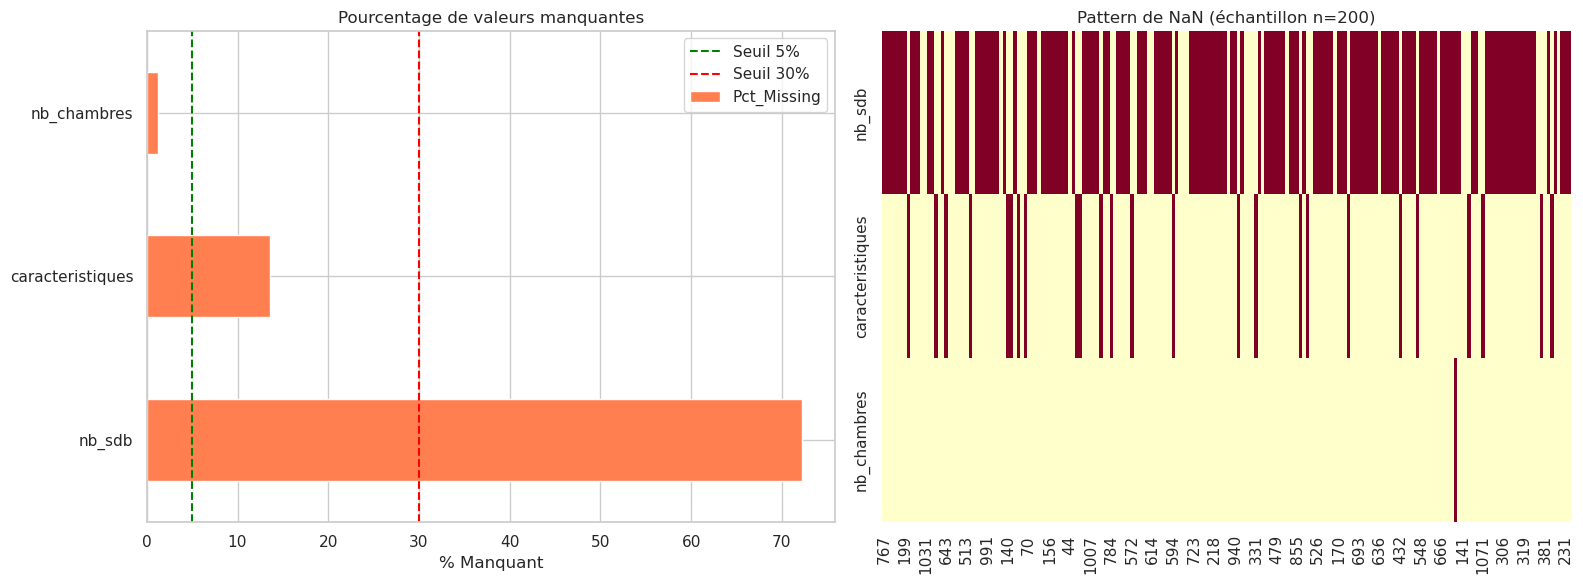

In [16]:
# 3.2 — Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique en barres
missing_df.plot(kind='barh', y='Pct_Missing', ax=axes[0], color='coral', legend=False)
axes[0].set_xlabel('% Manquant')
axes[0].set_title('Pourcentage de valeurs manquantes')
axes[0].axvline(x=5, color='green', linestyle='--', label='Seuil 5%')
axes[0].axvline(x=30, color='red', linestyle='--', label='Seuil 30%')
axes[0].legend()

# Heatmap (échantillon pour performance)
cols_na = missing_df.index.tolist()
sample_size = min(200, len(df))
sns.heatmap(df[cols_na].isnull().sample(sample_size, random_state=42).T,
            cbar=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title(f'Pattern de NaN (échantillon n={sample_size})')
plt.tight_layout()
plt.show()

In [17]:
# 3.3 — MCAR : tester la corrélation de 'is_missing' avec les autres variables
# Exemple avec surface_m2
if 'surface_m2' in df.columns and df['surface_m2'].isnull().sum() > 0:
    df['surface_m2_missing'] = df['surface_m2'].isnull().astype(int)
    num_cols = [c for c in df.select_dtypes(include='number').columns 
                if c not in ['id', 'surface_m2_missing', 'surface_m2']]
    
    if len(num_cols) > 0:
        corr = df[['surface_m2_missing'] + num_cols].corr()['surface_m2_missing'].drop('surface_m2_missing')
        print("📊 Corrélation 'surface_m2_missing' avec autres variables :")
        print(corr.abs().sort_values(ascending=False).head(10))
        print("\n→ Corrélations ≈ 0 → Confirme MCAR ✅")
        df.drop(columns='surface_m2_missing', inplace=True)

In [18]:
# 3.4 — MAR : nb_sdb manquant pour certains types de biens
# Vérifier si nb_sdb manquant est lié à d'autres variables
if 'nb_sdb' in df.columns and df['nb_sdb'].isnull().sum() > 0:
    print("📊 MAR — Variable nb_sdb :")
    mask_missing = df['nb_sdb'].isnull()
    
    # Comparer avec surface_m2 (terrains peuvent avoir 0 sdb)
    if 'surface_m2' in df.columns:
        print(f"  nb_sdb NaN → surface_m2 moyenne = {df.loc[mask_missing, 'surface_m2'].mean():.1f} m²")
        print(f"  nb_sdb OK  → surface_m2 moyenne = {df.loc[~mask_missing, 'surface_m2'].mean():.1f} m²")
    
    print("\n→ NaN peut dépendre du type de bien → MAR ✅")

📊 MAR — Variable nb_sdb :
  nb_sdb NaN → surface_m2 moyenne = 253.2 m²
  nb_sdb OK  → surface_m2 moyenne = 257.8 m²

→ NaN peut dépendre du type de bien → MAR ✅


In [19]:
# 3.5 — MNAR : Prix absent pour biens de luxe
if 'prix' in df.columns and df['prix'].isnull().sum() > 0:
    print("📊 MNAR — Prix manquant :")
    mask_missing = df['prix'].isnull()
    pct = mask_missing.mean() * 100
    
    # Vérifier si les prix manquants sont liés à des biens de grande valeur
    if 'surface_m2' in df.columns:
        print(f"  Prix NaN ({pct:.1f}%) → surface_m2 moyenne = {df.loc[mask_missing, 'surface_m2'].mean():.1f} m²")
        print(f"  Prix OK  → surface_m2 moyenne = {df.loc[~mask_missing, 'surface_m2'].mean():.1f} m²")
    
    if 'quartier' in df.columns:
        print(f"\n  Prix NaN par quartier :")
        print(df.loc[mask_missing, 'quartier'].value_counts().head())
    
    print("\n→ Prix manquant peut être 'Prix sur demande' pour biens de luxe → MNAR ✅")

In [20]:
# 3.6 — Appliquer les imputations

# MCAR : médiane pour numériques
mcar_cols = ['surface_m2', 'nb_chambres', 'nb_salons']
for col in mcar_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        med = df[col].median()
        n = df[col].isnull().sum()
        df[col].fillna(med, inplace=True)
        print(f"MCAR → {col} : {n} NaN → médiane ({med})")

# MAR : valeur par défaut selon contexte
if 'nb_sdb' in df.columns and df['nb_sdb'].isnull().sum() > 0:
    # Pour les terrains ou biens sans sdb, mettre 0
    df['nb_sdb'].fillna(0, inplace=True)
    print(f"MAR → nb_sdb : NaN → 0 (terrains/biens sans sdb)")

# MNAR : Pour le prix, on peut soit supprimer, soit imputer avec une valeur élevée
# Ici, on garde les NaN pour l'instant (sera géré en modélisation)
if 'prix' in df.columns and df['prix'].isnull().sum() > 0:
    print(f"MNAR → prix : {df['prix'].isnull().sum()} NaN conservés (sera géré en modélisation)")

print(f"\n✅ NaN restants : {df.isnull().sum().sum()}")
print(f"   Variables avec NaN : {(df.isnull().sum() > 0).sum()}")

MCAR → nb_chambres : 14 NaN → médiane (4.0)
MAR → nb_sdb : NaN → 0 (terrains/biens sans sdb)

✅ NaN restants : 157
   Variables avec NaN : 1


---
## 🔍 Étape 4 : Détection d'Outliers

> **Objectif** : IQR, Z-score, visualisation. Distinguer erreurs vs valeurs extrêmes plausibles.

In [21]:
def detect_outliers_iqr(series, k=1.5):
    """Détecte les outliers avec la méthode IQR"""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k*IQR
    upper_bound = Q3 + k*IQR
    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound

key_cols = ['prix', 'surface_m2', 'nb_chambres']
print("📊 Outliers — IQR × 1.5 :")
for col in key_cols:
    if col in df.columns:
        mask, lo, hi = detect_outliers_iqr(df[col].dropna())
        print(f"  {col:15s} : {mask.sum():3d} outliers  [{lo:.0f}, {hi:.0f}]")

print("\n📊 Outliers — Z-score > 3 :")
for col in key_cols:
    if col in df.columns:
        z = np.abs(stats.zscore(df[col].dropna()))
        print(f"  {col:15s} : {(z > 3).sum():3d} outliers")

📊 Outliers — IQR × 1.5 :
  prix            :  54 outliers  [-5450000, 12550000]
  surface_m2      :  93 outliers  [-75, 525]
  nb_chambres     :  16 outliers  [-2, 10]

📊 Outliers — Z-score > 3 :
  prix            :  21 outliers
  surface_m2      :  24 outliers
  nb_chambres     :  16 outliers


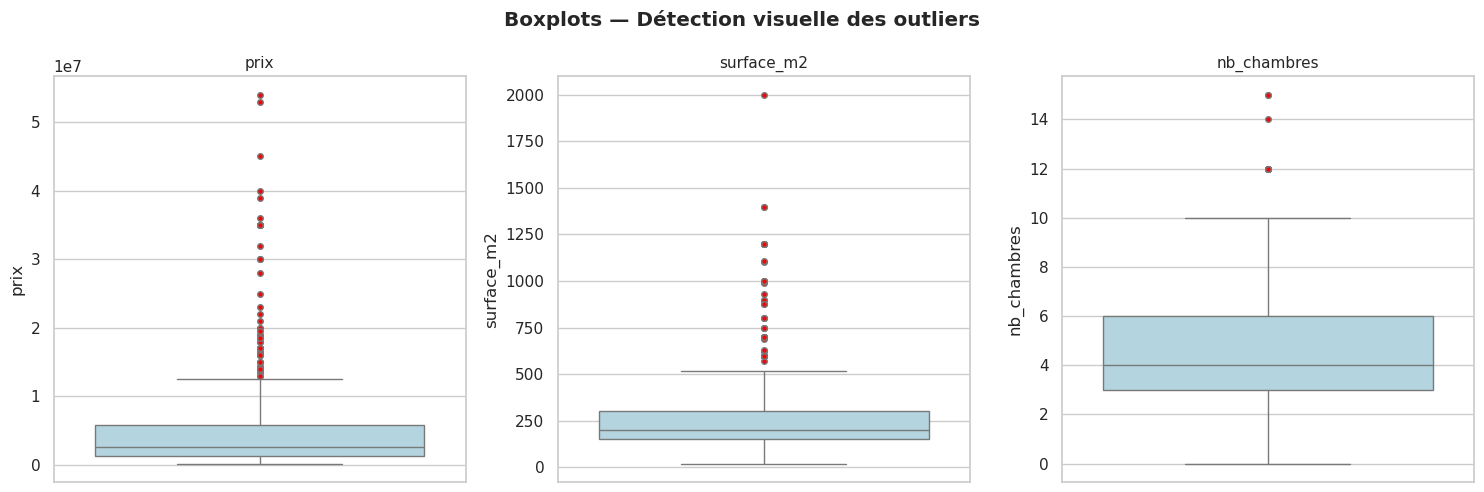

In [22]:
# Boxplots
key_cols_available = [col for col in ['prix', 'surface_m2', 'nb_chambres'] if col in df.columns]
n_cols = len(key_cols_available)
if n_cols > 0:
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    if n_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(key_cols_available):
        sns.boxplot(y=df[col], ax=axes[i], color='lightblue',
                    flierprops=dict(markerfacecolor='red', markersize=4))
        axes[i].set_title(col, fontsize=11)
    plt.suptitle("Boxplots — Détection visuelle des outliers", fontweight='bold')
    plt.tight_layout()
    plt.show()

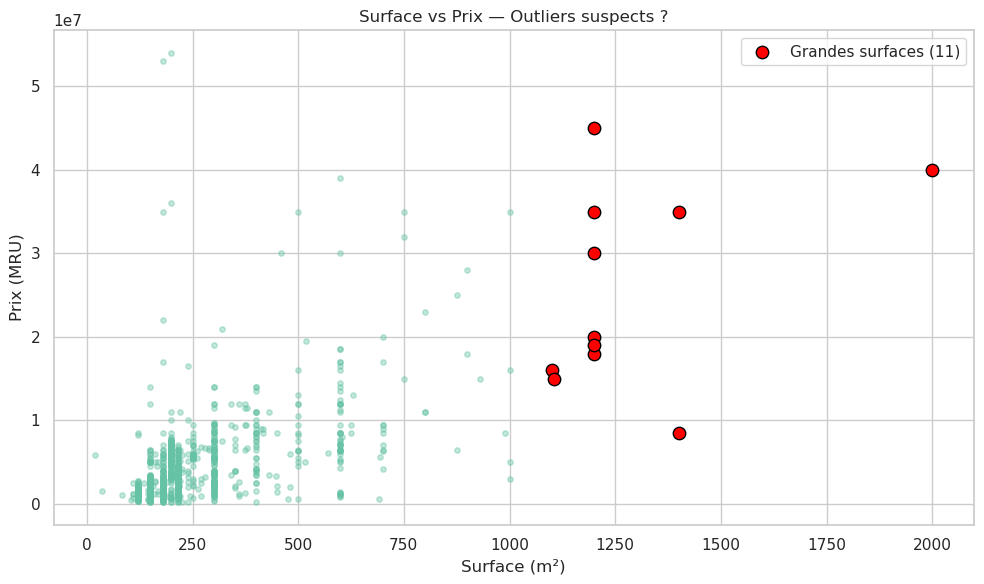

🤔 Contexte métier mauritanien :
   - Prix élevés (> 100M MRU) = villas de luxe à Tevragh Zeina → plausibles
   - Surfaces > 1000 m² = terrains ou grandes propriétés → plausibles
   - Prix très bas (< 500K MRU) pour grandes surfaces → suspect


In [23]:
# Scatter surface_m2 vs prix — identifier les outliers suspects
if 'surface_m2' in df.columns and 'prix' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df['surface_m2'], df['prix'], alpha=0.4, s=15)
    
    # Identifier les points extrêmes
    if (df['surface_m2'] > 1000).sum() > 0:
        extreme = df[df['surface_m2'] > 1000]
        ax.scatter(extreme['surface_m2'], extreme['prix'], color='red', s=80,
                   edgecolors='black', zorder=5, label=f'Grandes surfaces ({len(extreme)})')
    
    ax.set_xlabel('Surface (m²)')
    ax.set_ylabel('Prix (MRU)')
    ax.set_title('Surface vs Prix — Outliers suspects ?')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print("🤔 Contexte métier mauritanien :")
    print("   - Prix élevés (> 100M MRU) = villas de luxe à Tevragh Zeina → plausibles")
    print("   - Surfaces > 1000 m² = terrains ou grandes propriétés → plausibles")
    print("   - Prix très bas (< 500K MRU) pour grandes surfaces → suspect")

In [24]:
# Catégoriel : classes rares
print("📊 Classes rares (<10 obs) :")
for col in df.select_dtypes(include='object').columns:
    if col not in ['titre', 'description', 'caracteristiques']:  # Exclure les colonnes texte
        counts = df[col].value_counts()
        rare = counts[counts < 10]
        if len(rare) > 0:
            print(f"  {col} : {list(rare.index)[:5]}")  # Limiter à 5 pour l'affichage

📊 Classes rares (<10 obs) :


---
## 📊 Étape 5 : Analyse Univariée

> **Objectif** : Distribution de chaque variable — histogrammes, KDE, stats, normalité.

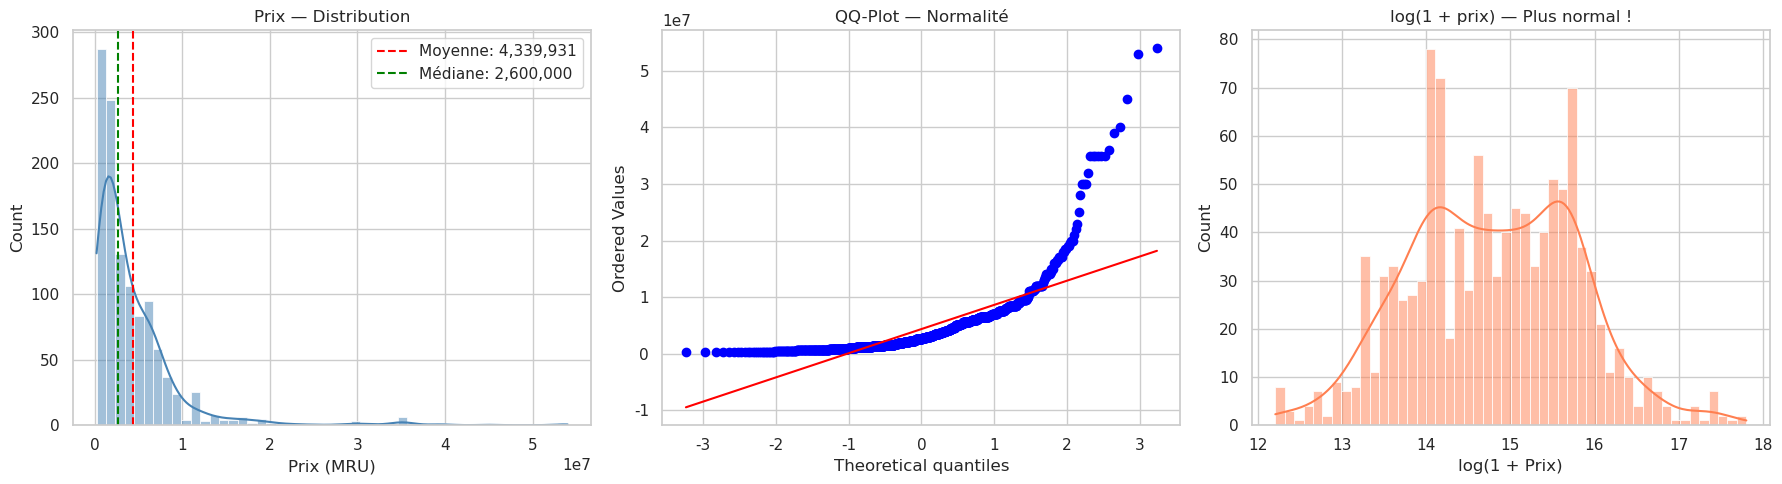

count    1.153000e+03
mean     4.339931e+06
std      5.451494e+06
min      2.000000e+05
25%      1.300000e+06
50%      2.600000e+06
75%      5.800000e+06
max      5.400000e+07
Name: prix, dtype: float64

Skewness : 4.114
Kurtosis : 24.060

🧪 Shapiro-Wilk (n=500) : p=0.000000 → Non-normal


In [25]:
# 5.1 — Variable cible : prix
if 'prix' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogramme
    sns.histplot(df['prix'].dropna(), bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(df['prix'].mean(), color='red', linestyle='--', 
                    label=f"Moyenne: {df['prix'].mean():,.0f}")
    axes[0].axvline(df['prix'].median(), color='green', linestyle='--', 
                    label=f"Médiane: {df['prix'].median():,.0f}")
    axes[0].set_title('Prix — Distribution')
    axes[0].set_xlabel('Prix (MRU)')
    axes[0].legend()
    
    # QQ-plot
    stats.probplot(df['prix'].dropna(), dist='norm', plot=axes[1])
    axes[1].set_title('QQ-Plot — Normalité')
    
    # Transformation log
    log_prix = np.log1p(df['prix'].dropna())
    sns.histplot(log_prix, bins=50, kde=True, ax=axes[2], color='coral')
    axes[2].set_title('log(1 + prix) — Plus normal !')
    axes[2].set_xlabel('log(1 + Prix)')
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    print(df['prix'].describe())
    print(f"\nSkewness : {df['prix'].skew():.3f}")
    print(f"Kurtosis : {df['prix'].kurt():.3f}")
    
    # Test de normalité (échantillon pour performance)
    sample_size = min(500, df['prix'].notna().sum())
    stat, pval = stats.shapiro(df['prix'].dropna().sample(sample_size, random_state=42))
    print(f"\n🧪 Shapiro-Wilk (n={sample_size}) : p={pval:.6f} → {'Non-normal' if pval < 0.05 else 'Normal'}")

AttributeError: 'numpy.ndarray' object has no attribute 'xaxis'

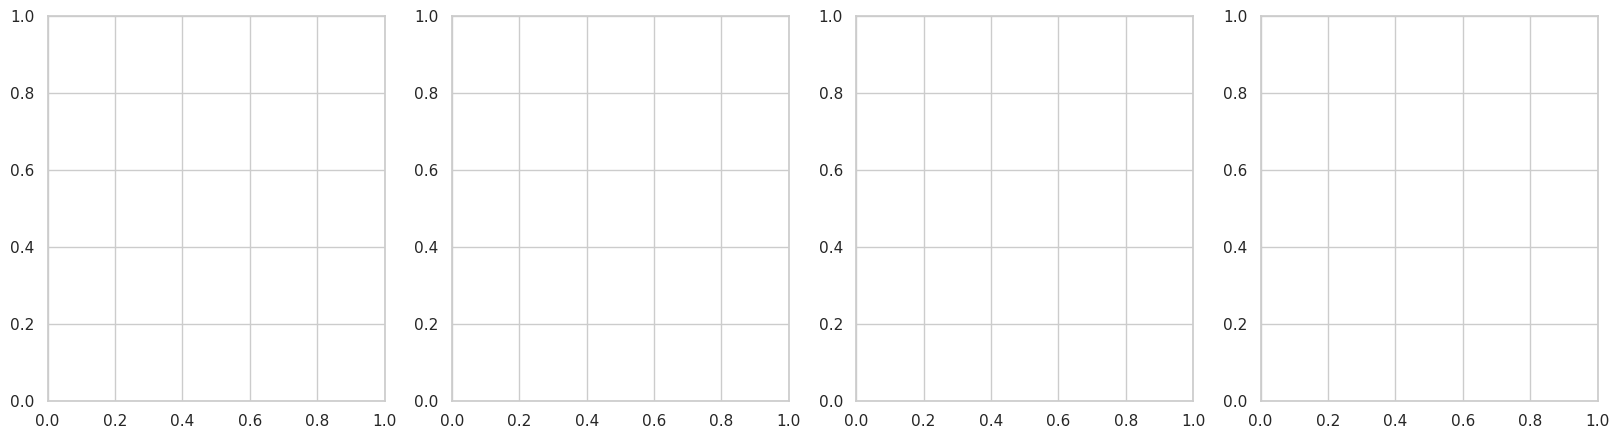

In [26]:
# 5.2 — Histogrammes des variables numériques clés
num_plot = [col for col in ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb'] if col in df.columns]

if len(num_plot) > 0:
    n_cols = min(4, len(num_plot))
    n_rows = (len(num_plot) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1) if n_cols > 1 else [axes]
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, col in enumerate(num_plot):
        row = i // n_cols
        col_idx = i % n_cols
        ax = axes[row][col_idx] if n_rows > 1 else axes[col_idx]
        
        sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax, color=f'C{i}')
        ax.axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7)
        skew_val = df[col].skew()
        ax.set_title(f'{col} (skew={skew_val:.2f})')
    
    # Masquer les axes inutilisés
    for i in range(len(num_plot), n_rows * n_cols):
        row = i // n_cols
        col_idx = i % n_cols
        if n_rows > 1:
            axes[row][col_idx].set_visible(False)
        else:
            axes[col_idx].set_visible(False)
    
    plt.suptitle("Distributions univariées — Variables numériques", fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

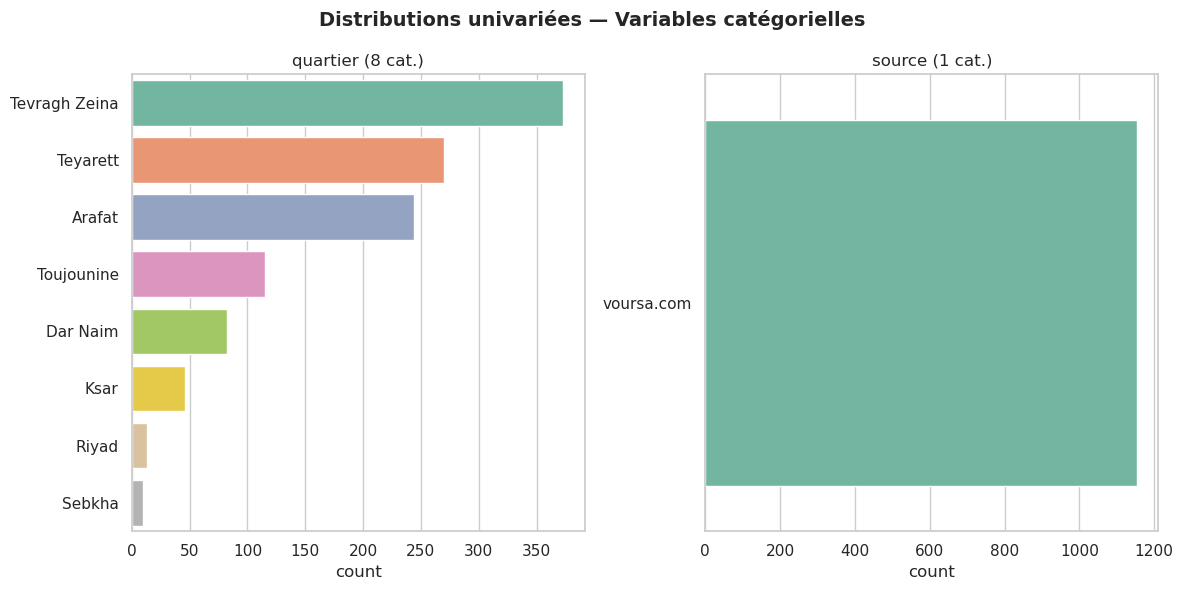

In [27]:
# 5.3 — Variables catégorielles : barplots top catégories
cat_plot = [col for col in ['quartier', 'source'] if col in df.columns]

if len(cat_plot) > 0:
    n_cols = len(cat_plot)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 6))
    if n_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(cat_plot):
        order = df[col].value_counts().head(10).index
        sns.countplot(y=df[col], ax=axes[i], order=order, palette='Set2')
        axes[i].set_title(f'{col} ({df[col].nunique()} cat.)')
        axes[i].set_ylabel('')
    
    plt.suptitle("Distributions univariées — Variables catégorielles", fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

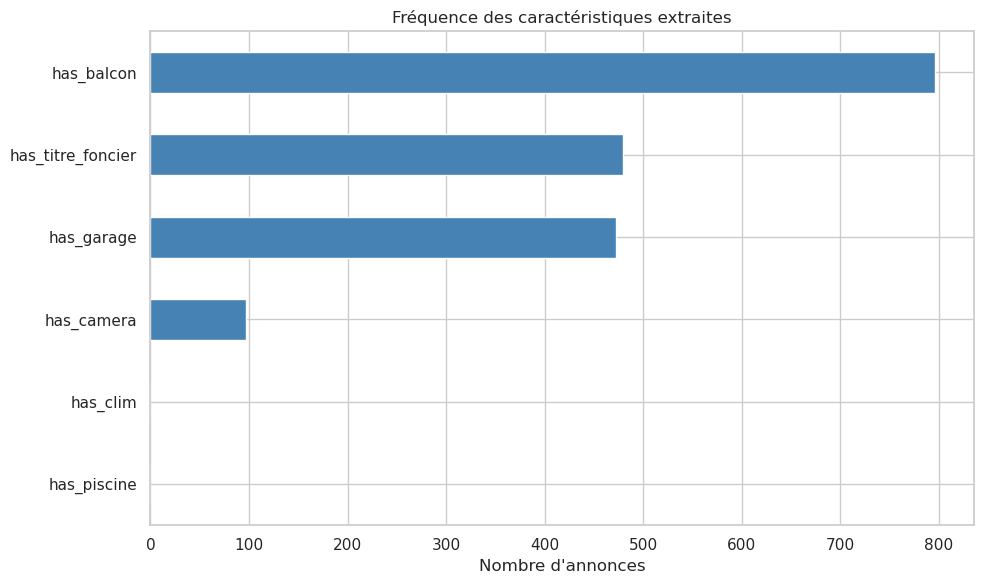

In [28]:
# 5.4 — Fréquences des caractéristiques extraites
bool_cols = [col for col in df.columns if col.startswith('has_')]
if len(bool_cols) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    freq = pd.Series({col: df[col].sum() for col in bool_cols}).sort_values(ascending=True)
    freq.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Nombre d\'annonces')
    ax.set_title('Fréquence des caractéristiques extraites')
    plt.tight_layout()
    plt.show()

---
## 📈 Étape 6 : Analyse Bivariée

> **Objectif** : Relations entre 2 variables — Num×Num (scatter, corrélation), Num×Cat (boxplot, ANOVA), Cat×Cat (Chi²).

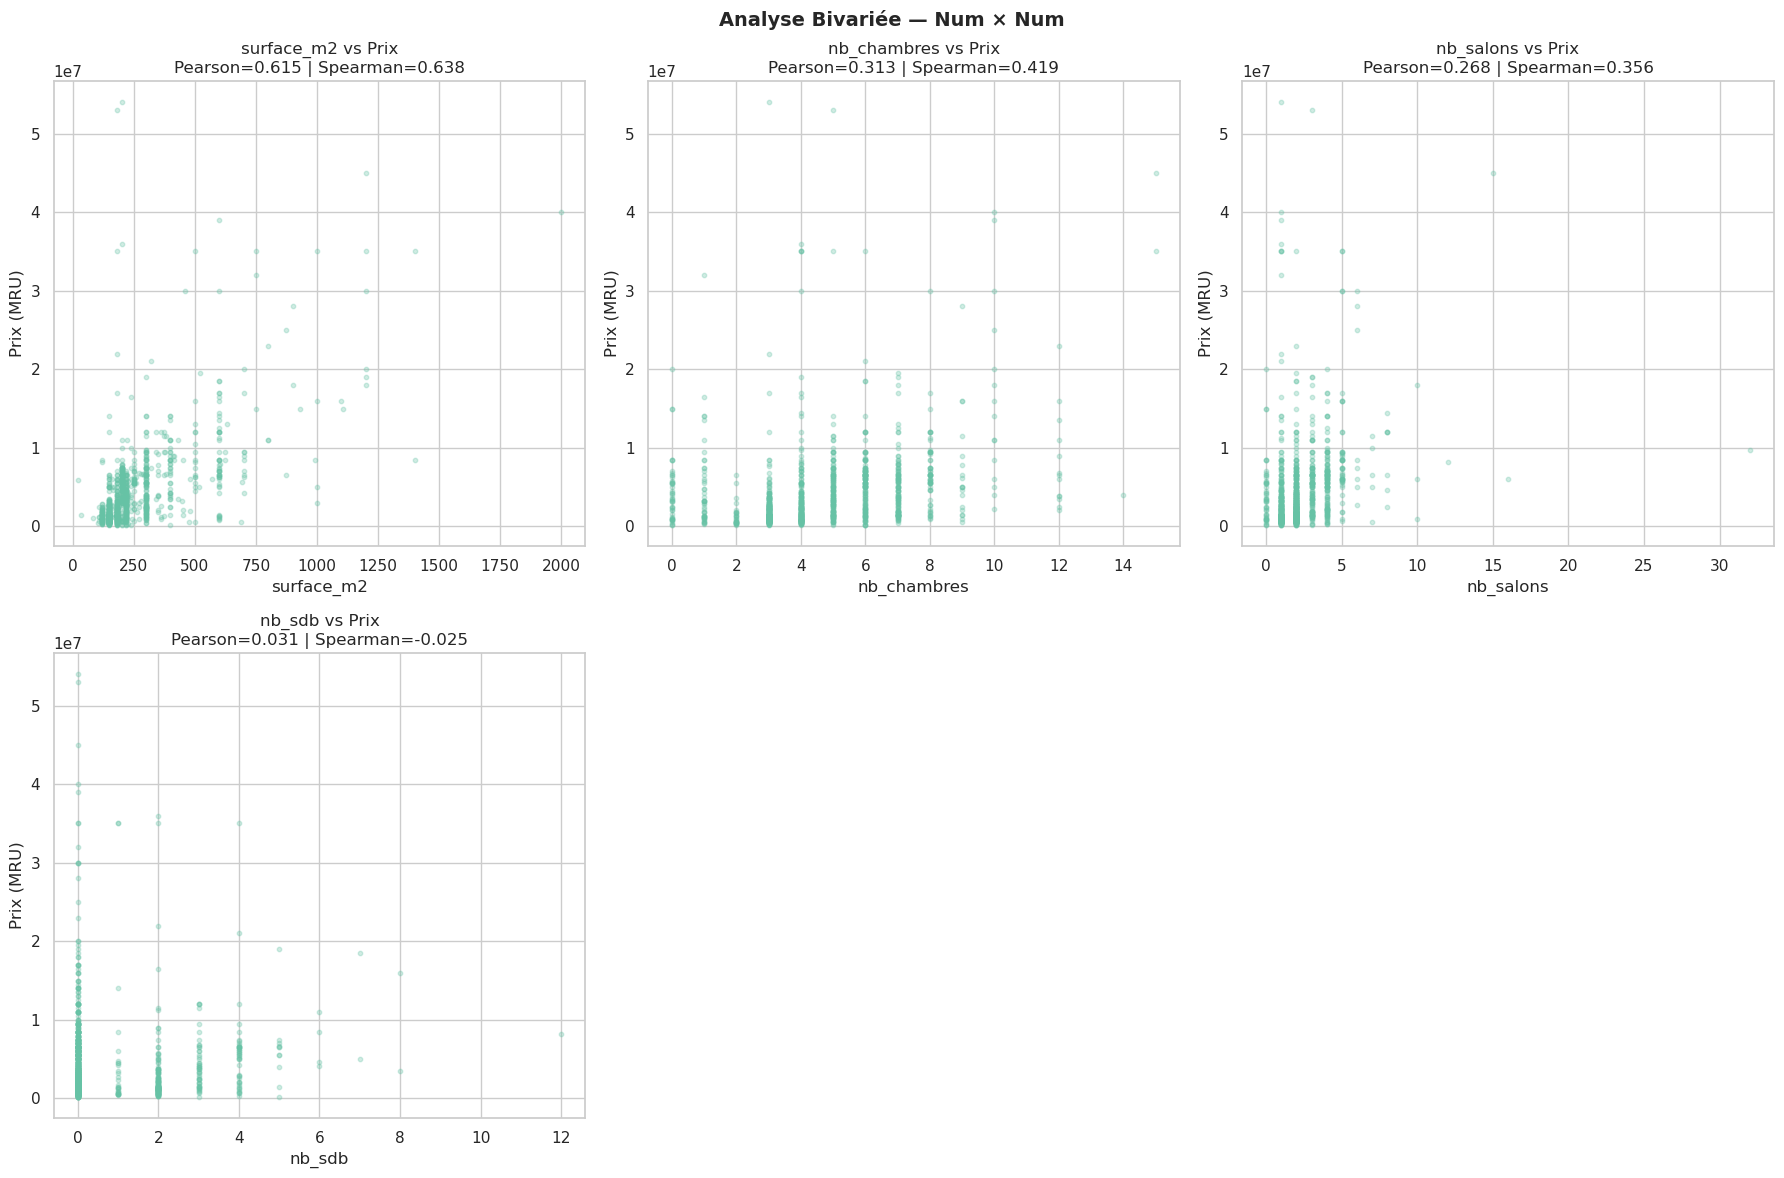

In [29]:
# 6.1 — Num × Num : Scatter plots vs prix
if 'prix' in df.columns:
    scatter_vars = [col for col in ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb'] if col in df.columns]
    
    if len(scatter_vars) > 0:
        n_cols = min(3, len(scatter_vars))
        n_rows = (len(scatter_vars) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
        
        if n_rows == 1:
            axes = axes.reshape(1, -1) if n_cols > 1 else [axes]
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        for i, col in enumerate(scatter_vars):
            row = i // n_cols
            col_idx = i % n_cols
            ax = axes[row][col_idx] if n_rows > 1 else axes[col_idx]
            
            ax.scatter(df[col], df['prix'], alpha=0.3, s=10)
            
            # Corrélation
            r_pearson = df[col].corr(df['prix'])
            r_spearman = df[col].corr(df['prix'], method='spearman')
            ax.set_title(f'{col} vs Prix\nPearson={r_pearson:.3f} | Spearman={r_spearman:.3f}')
            ax.set_xlabel(col)
            ax.set_ylabel('Prix (MRU)')
        
        # Masquer les axes inutilisés
        for i in range(len(scatter_vars), n_rows * n_cols):
            row = i // n_cols
            col_idx = i % n_cols
            if n_rows > 1:
                axes[row][col_idx].set_visible(False)
            else:
                axes[col_idx].set_visible(False)
        
        plt.suptitle("Analyse Bivariée — Num × Num", fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()

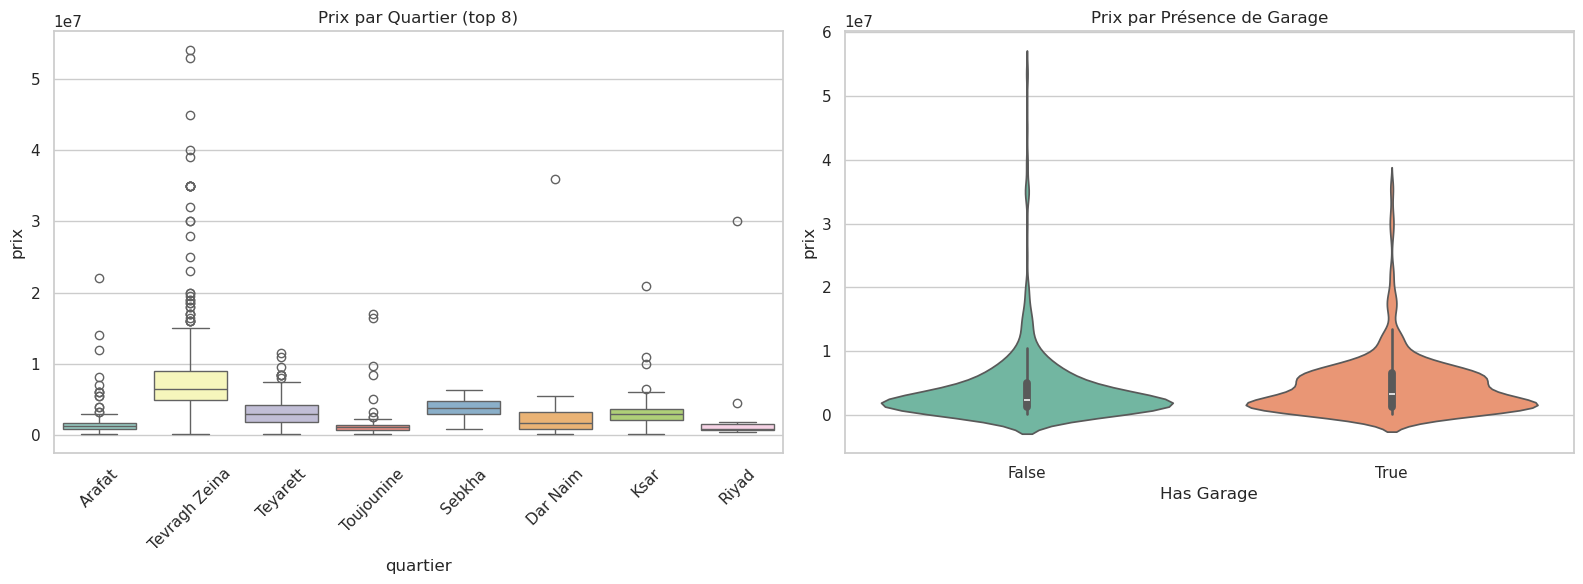

In [30]:
# 6.2 — Num × Cat : Boxplots / Violin plots
if 'prix' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Prix par quartier (top 8)
    if 'quartier' in df.columns:
        top_quartiers = df['quartier'].value_counts().head(8).index
        df_top = df[df['quartier'].isin(top_quartiers)]
        sns.boxplot(x='quartier', y='prix', data=df_top, ax=axes[0], palette='Set3')
        axes[0].set_title('Prix par Quartier (top 8)')
        axes[0].tick_params(axis='x', rotation=45)
    
    # Prix par présence de garage
    if 'has_garage' in df.columns:
        sns.violinplot(x='has_garage', y='prix', data=df, ax=axes[1], palette='Set2')
        axes[1].set_title('Prix par Présence de Garage')
        axes[1].set_xlabel('Has Garage')
    
    plt.tight_layout()
    plt.show()

In [32]:
# 6.3 — Test ANOVA / t-test
if 'prix' in df.columns:
    print("🧪 Tests statistiques — Num × Cat :")
    print("-" * 50)
    
    # ANOVA : Quartier → Prix
    if 'quartier' in df.columns:
        top_quartiers = df['quartier'].value_counts().head(5).index
        groups = [df[df['quartier'] == q]['prix'].dropna().values for q in top_quartiers if len(df[df['quartier'] == q]['prix'].dropna()) > 0]
        
        if len(groups) >= 2:
            f_stat, p_val = stats.f_oneway(*groups)
            print(f"ANOVA  Quartier (top 5) → Prix : F={f_stat:.2f}, p={p_val:.2e} {'***' if p_val<0.001 else ''}")
            
            # Kruskal-Wallis (non-paramétrique)
            h_stat, p_val = stats.kruskal(*groups)
            print(f"Kruskal Quartier (top 5) → Prix : H={h_stat:.2f}, p={p_val:.2e} {'***' if p_val<0.001 else ''}")
    
    # t-test : has_garage → Prix
    if 'has_garage' in df.columns:
        g_yes = df[df['has_garage']==True]['prix'].dropna()
        g_no = df[df['has_garage']==False]['prix'].dropna()
        
        if len(g_yes) > 0 and len(g_no) > 0:
            t_stat, p_val = stats.ttest_ind(g_yes, g_no)
            print(f"\nt-test has_garage → Prix : t={t_stat:.2f}, p={p_val:.2e} {'***' if p_val<0.001 else ''}")

🧪 Tests statistiques — Num × Cat :
--------------------------------------------------
ANOVA  Quartier (top 5) → Prix : F=97.76, p=5.00e-71 ***
Kruskal Quartier (top 5) → Prix : H=528.32, p=5.02e-113 ***

t-test has_garage → Prix : t=1.50, p=1.35e-01 


In [33]:
# 6.4 — Cat × Cat : Test Chi² (contingence)
if 'quartier' in df.columns and 'source' in df.columns:
    from scipy.stats import chi2_contingency
    
    # Top 5 quartiers et sources
    top_quartiers = df['quartier'].value_counts().head(5).index
    top_sources = df['source'].value_counts().head(3).index
    
    df_subset = df[df['quartier'].isin(top_quartiers) & df['source'].isin(top_sources)]
    
    if len(df_subset) > 0:
        ct = pd.crosstab(df_subset['quartier'], df_subset['source'])
        chi2, p, dof, expected = chi2_contingency(ct)
        print("📊 Cat × Cat : Quartier × Source")
        print(f"   Chi² = {chi2:.2f}, p = {p:.4f}, ddl = {dof}")
        print(f"   → {'Dépendance significative' if p < 0.05 else 'Indépendance'}")
        
        print("\nTable de contingence :")
        display(ct)

📊 Cat × Cat : Quartier × Source
   Chi² = 0.00, p = 1.0000, ddl = 0
   → Indépendance

Table de contingence :


source,voursa.com
quartier,
Arafat,244
Dar Naim,82
Tevragh Zeina,373
Teyarett,270
Toujounine,115


---
## 🧮 Étape 7 : Analyse Multivariée

> **Objectif** : Heatmap de corrélations, VIF (multicollinéarité), PCA, Pairplots.

In [34]:
# 7.1 — Matrice de corrélation
num_df = df.select_dtypes(include='number').drop(columns=['id'], errors='ignore')
if 'prix' in num_df.columns:
    corr_matrix = num_df.corr()
    
    # Top corrélations avec prix
    print("📊 Top 15 corrélations avec prix :")
    print(corr_matrix['prix'].abs().sort_values(ascending=False).head(16))

📊 Top 15 corrélations avec prix :
prix           1.000000
surface_m2     0.615152
nb_chambres    0.313188
nb_salons      0.268210
nb_sdb         0.030811
Name: prix, dtype: float64


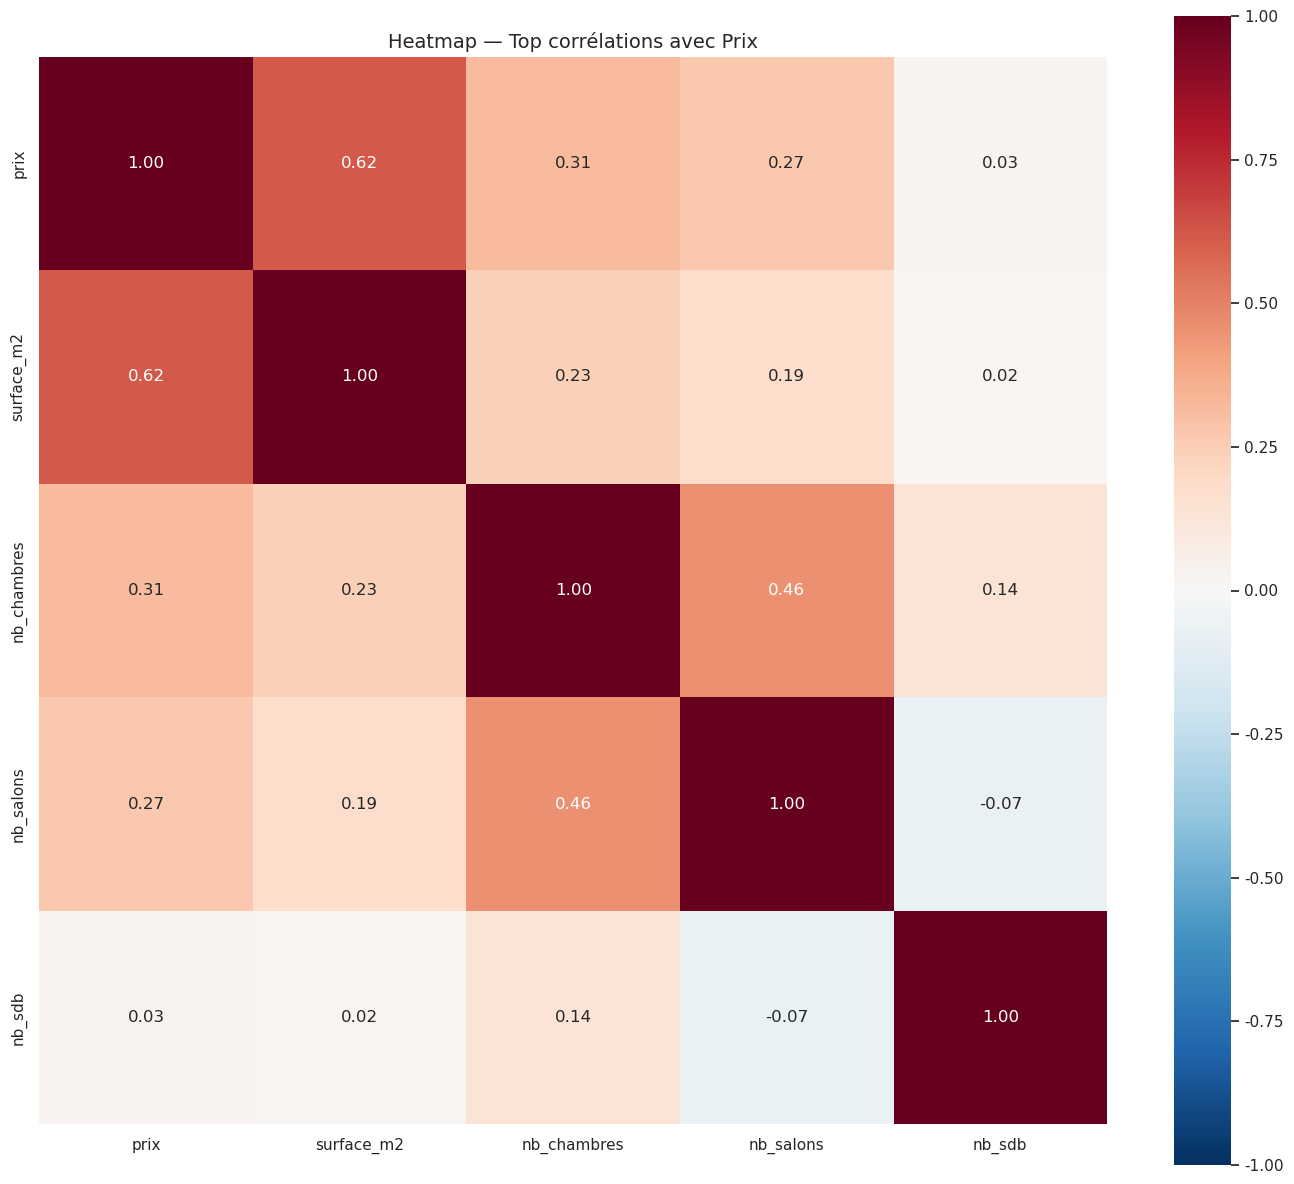

In [35]:
# Heatmap
if 'prix' in num_df.columns:
    # Sélectionner les 15 variables les plus corrélées avec prix
    top_corr = corr_matrix['prix'].abs().sort_values(ascending=False).head(16).index
    top_corr = [col for col in top_corr if col in num_df.columns]
    
    if len(top_corr) > 1:
        fig, ax = plt.subplots(figsize=(14, 12))
        sns.heatmap(num_df[top_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1, ax=ax, square=True)
        ax.set_title('Heatmap — Top corrélations avec Prix', fontsize=14)
        plt.tight_layout()
        plt.show()

In [36]:
# 7.2 — VIF (Variance Inflation Factor) — Multicollinéarité
from sklearn.preprocessing import StandardScaler

# Sélectionner les variables numériques continues
vif_cols = [col for col in ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'prix'] if col in df.columns]
vif_cols = [col for col in vif_cols if col != 'prix']  # Exclure la variable cible

if len(vif_cols) >= 2:
    X_vif = df[vif_cols].dropna()
    
    if len(X_vif) > 0:
        X_scaled = StandardScaler().fit_transform(X_vif)
        
        # Calculer VIF
        from numpy.linalg import inv
        corr = np.corrcoef(X_scaled.T)
        try:
            vif_values = np.diag(inv(corr))
        except:
            vif_values = np.diag(np.linalg.pinv(corr))
        
        vif_df = pd.DataFrame({'Variable': vif_cols, 'VIF': vif_values}).sort_values('VIF', ascending=False)
        print("📊 VIF — Multicollinéarité :")
        print("   VIF > 5 → multicollinéarité modérée")
        print("   VIF > 10 → multicollinéarité forte\n")
        display(vif_df)

📊 VIF — Multicollinéarité :
   VIF > 5 → multicollinéarité modérée
   VIF > 10 → multicollinéarité forte



,Variable,VIF
1,nb_chambres,1.348860
2,nb_salons,1.302844
0,surface_m2,1.066844
3,nb_sdb,1.041372


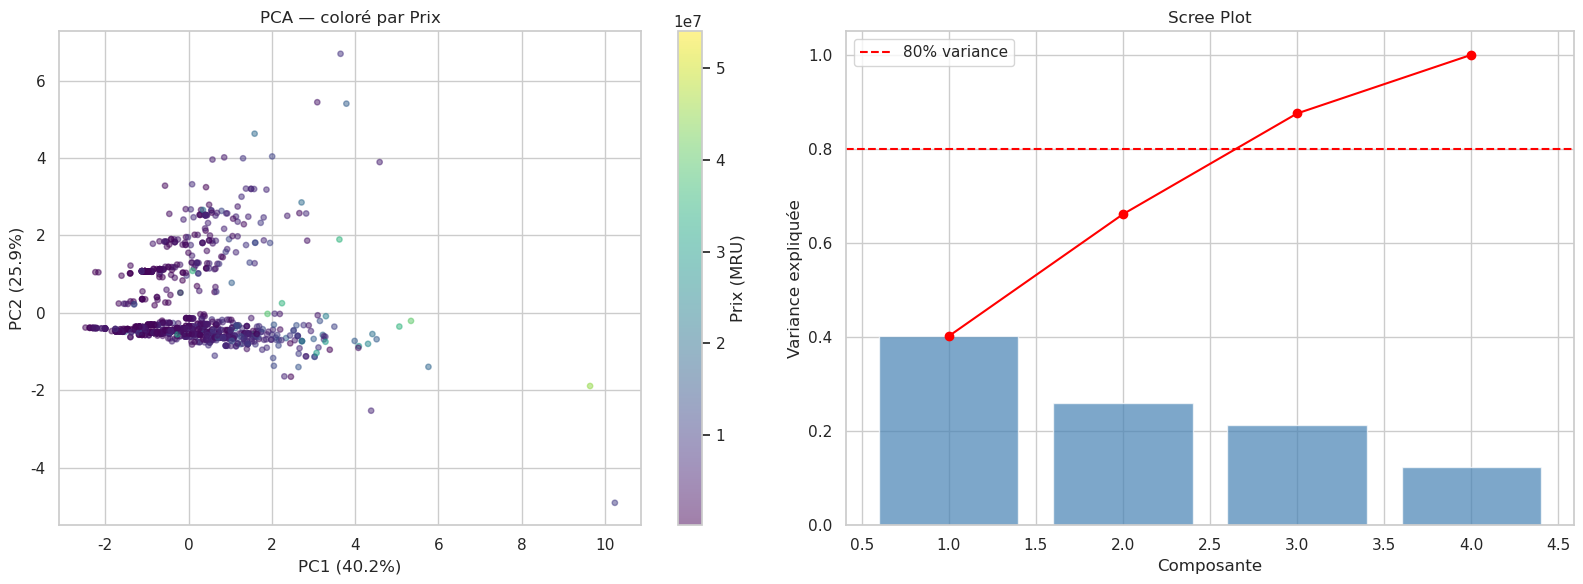


📊 Variance expliquée par PC1+PC2 : 66.1%


In [37]:
# 7.3 — PCA : réduction dimensionnelle pour visualiser
from sklearn.decomposition import PCA

features = [col for col in ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb'] if col in df.columns]

if len(features) >= 2:
    X = df[features].dropna()
    
    if len(X) > 0:
        X_scaled = StandardScaler().fit_transform(X)
        
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Scatter coloré par prix
        if 'prix' in df.columns:
            prix_values = df.loc[X.index, 'prix']
            sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=prix_values,
                             cmap='viridis', alpha=0.5, s=15)
            plt.colorbar(sc, ax=axes[0], label='Prix (MRU)')
        else:
            axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=15)
        
        axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
        axes[0].set_title('PCA — coloré par Prix')
        
        # Variance expliquée
        pca_full = PCA().fit(X_scaled)
        axes[1].bar(range(1, len(features)+1), pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
        axes[1].plot(range(1, len(features)+1), np.cumsum(pca_full.explained_variance_ratio_), 'ro-')
        axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% variance')
        axes[1].set_xlabel('Composante')
        axes[1].set_ylabel('Variance expliquée')
        axes[1].set_title('Scree Plot')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        print(f"\n📊 Variance expliquée par PC1+PC2 : {pca.explained_variance_ratio_.sum():.1%}")

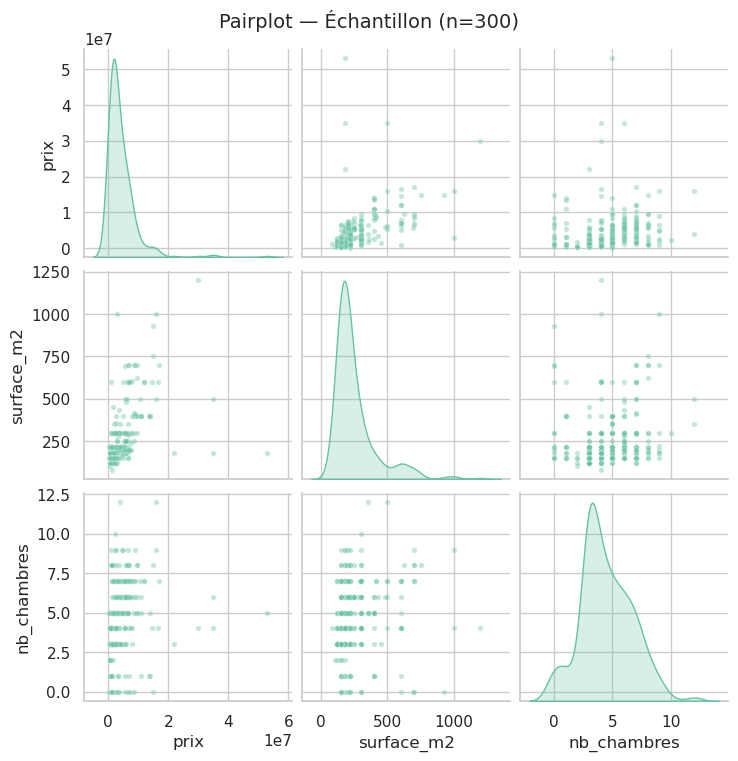

In [38]:
# 7.4 — Pairplot (échantillon pour performance)
pairplot_cols = [col for col in ['prix', 'surface_m2', 'nb_chambres'] if col in df.columns]

if len(pairplot_cols) >= 2:
    sample = df[pairplot_cols].sample(min(300, len(df)), random_state=42).dropna()
    
    if len(sample) > 0:
        g = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                         height=2.5)
        g.figure.suptitle("Pairplot — Échantillon (n=300)", y=1.01, fontsize=14)
        plt.show()

---
## ⚙️ Étape 8 : Préparation Finale

> **Objectif** : Encodage, normalisation, split train/test, pipeline reproductible.

In [ ]:
# 8.1 — Feature Engineering
print("🔧 Feature Engineering :")

# Prix au m²
if 'prix' in df.columns and 'surface_m2' in df.columns:
    df['prix_m2'] = df['prix'] / df['surface_m2']
    df.loc[df['surface_m2'] == 0, 'prix_m2'] = np.nan  # Éviter division par zéro
    print("  ✅ prix_m2 = prix / surface_m2")

# Log transform du prix
if 'prix' in df.columns:
    df['log_prix'] = np.log1p(df['prix'])
    print("  ✅ log_prix = log(1 + prix)")

# Nombre total de pièces
if 'nb_chambres' in df.columns and 'nb_salons' in df.columns:
    df['nb_pieces_total'] = df['nb_chambres'] + df['nb_salons']
    print("  ✅ nb_pieces_total = nb_chambres + nb_salons")

print(f"\n📊 Nouvelles colonnes créées")
print(f"   Dimensions : {df.shape}")

In [ ]:
# 8.2 — Encodage des variables catégorielles
from sklearn.preprocessing import LabelEncoder

# One-Hot Encoding pour quartier et source
nominal_cols = [col for col in ['quartier', 'source'] if col in df.columns]

if len(nominal_cols) > 0:
    # Limiter le nombre de catégories pour One-Hot (garder top N)
    df_encoded = df.copy()
    
    for col in nominal_cols:
        # Garder top 10 catégories, regrouper le reste en "Autre"
        top_cats = df[col].value_counts().head(10).index
        df_encoded[col] = df[col].apply(lambda x: x if x in top_cats else 'Autre')
    
    # One-Hot Encoding
    df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True, dtype=int)
    print(f"One-Hot → {nominal_cols}")
    print(f"Dimensions après encodage : {df_encoded.shape}")
    
    # Mettre à jour df
    df = df_encoded

In [ ]:
### 📌 Note
> **La modélisation (split train/test, entraînement des modèles, validation croisée) sera effectuée dans le notebook `04_modeling.ipynb`**

---
## 📝 Documentation — Livrable

### Décisions prises
| Étape | Décision | Justification |
|-------|----------|---------------|
| Doublons | Supprimés (keep='first') | Lignes identiques sauf id |
| Quartiers | Standardisés (Title Case) | Uniformiser les variantes orthographiques |
| Prix négatifs | → NaN | Impossible pour un prix |
| Surfaces négatives | → NaN | Impossible pour une surface |
| Caractéristiques | Parsées en booléens | Extraire has_garage, has_piscine, etc. |
| MCAR NaN | Médiane | <5% manquant, aucun pattern |
| MAR NaN | Valeur par défaut (0 pour nb_sdb) | NaN signifie absence (ex: terrain) |
| MNAR NaN | Conservés | Prix sur demande → à gérer en modélisation |
| Outliers | Marqués, non supprimés | Valeurs extrêmes mais plausibles (villas de luxe) |
| Encodage | One-Hot pour quartier/source | Variables nominales |
| Scaling | StandardScaler après split | Éviter le data leakage |

### Hypothèses & Limites
- Les valeurs manquantes dans `nb_sdb` sont structurelles (terrains sans sdb)
- Les prix manquants peuvent être "Prix sur demande" pour biens de luxe
- Les outliers (prix élevés) sont plausibles pour le marché mauritanien (villas à Tevragh Zeina)
- Le dataset contient des textes en arabe (titre, description) - non analysés dans cette EDA
- Les caractéristiques sont parsées de manière basique (peut être amélioré)

### Prochaines étapes
1. **Feature Engineering & Modélisation** → Voir `04_modeling.ipynb`
   - Feature Engineering avancé (interactions, polynômes, age_annonce)
   - Test de plusieurs modèles (Linear, Ridge, Lasso, Random Forest, Gradient Boosting, XGBoost)
   - Validation croisée 5-fold
   - Sélection du meilleur modèle
2. Analyse des textes (description, titre) avec NLP (optionnel)
3. Enrichissement géographique (si pas encore fait)

---
*🎓 Notebook créé pour le projet Capstone - Prédiction des Prix Immobiliers en Mauritanie*  
*📅 SupNum - Machine Learning Course - Mohamed*  
*Février 2026*